Q2
(a) Apply gamma correction to the L plane in the L∗a∗ b∗ color space and state the gamma value.

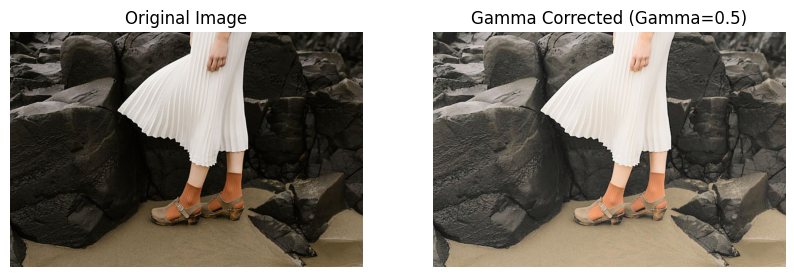

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#load the image in grayscale mode
f = cv.imread('/Users/sahansach/Documents/MSC/Semester 3/Computer Vision/Assignment 01/a1images/highlights_and_shadows.jpg')
assert f is not None

# Convert to Lab color space
lab = cv.cvtColor(f, cv.COLOR_BGR2LAB)

# Split channels
L, a, b = cv.split(lab)

# Normalize L to [0,1]
L_norm = L / 255.0

# Apply gamma correction with gamma = 0.5
gamma = 0.5
L_gamma = np.power(L_norm, gamma)

# Rescale back to [0,255]
L_corrected = np.uint8(L_gamma * 255)

# Merge channels back
lab_corrected = cv.merge([L_corrected, a, b])
img_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)

# Show original vs corrected
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(cv.cvtColor(f, cv.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Gamma Corrected (Gamma=0.5)")
plt.imshow(cv.cvtColor(img_corrected, cv.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


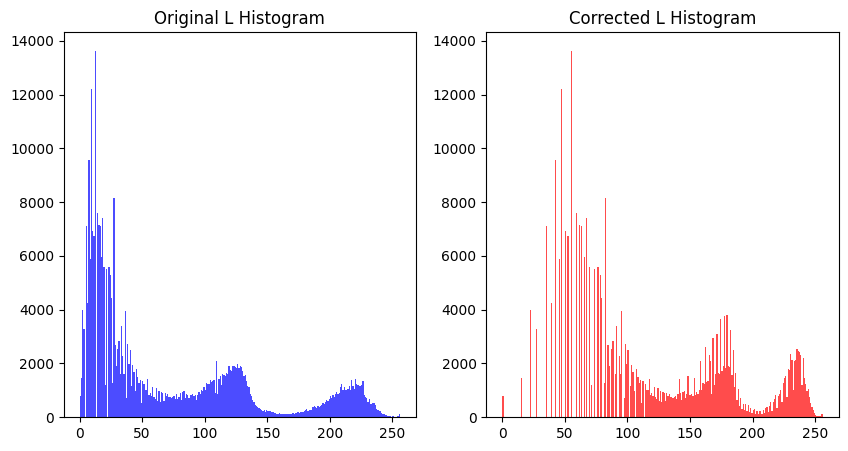

In [5]:
# Plot histograms of L channel before and after correction
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original L Histogram")
plt.hist(L.ravel(), bins=256, range=(0,256), color='blue', alpha=0.7)

plt.subplot(1,2,2)
plt.title("Corrected L Histogram")
plt.hist(L_corrected.ravel(), bins=256, range=(0,256), color='red', alpha=0.7)

plt.show()
